In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import operator
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from util.api import get_versions_df, get_update_count_df, get_count_updated_packages_by_lts, get_lts_list

%matplotlib inline
plt.style.use('classic')

In [2]:
lts_list = get_lts_list()
df_list = []
df_by_category_list = []

for idx, lts in enumerate(lts_list):
    df = pd.read_pickle(f'../../data/dfs/lts-{lts}/lts-{lts}.df')
    df_list.append(df)

# Research Questions (RQs)

- **RQ 1.** What packages are the most used? Which of them are outside from the Stackage selection?
- **RQ 2.** How many dependencies of packages are outside from the Stackage selection (in)directly?
- **RQ 3.** How frequently are the packages updated? 

Regarding monads, we analyze the evolution of dependencies of monad modules available in the mtl package:

- **RQ 4.** How has the use of monads evolved?
- **RQ 5.** Are there packages that stopped using monads?

## RQ 3. How frequently are the packages updated? 

Construimos un nuevo DafaFrame que nos muestra la version de cada paquete en cada LTS que llamamos `versions_df`. Procesamos este DataFrame contando la cantidad de veces en que cada paquete actualizo su version a lo largo del tiempo. Luego, calculamos el porcentaje de paquetes que actualizo su version en cada LTS respecto a la cantidad de paquetes totales en el snapshot anterior.

- La primera version tiene alrededor de 800 paquetes y el porcentaje de actualizacion depende de la version anterior
- Al inicio de las versiones se actualizaron una gran cantidad de paquetes entre cada snapshot (2-22, 3-22 y 6-35), sin embargo el periodo de tiempo (+6 meses) existente entre estas versiones es superior, ya que no existia regularidad en la publicacion de versiones
- Durante las versiones 12-14, 12-26, 13-11 y 13-19 se ve una disminucion en la cantidad de paquetes actualziados sin emargo el margen de tiempo (1-3 meses) entre estas versiones es bastante menor a las otras publicacinoes.
- En promedio se actializan el 28% de los paquetes y la desviacion estandar X

In [3]:
versions_df = get_versions_df(df_list)

In [4]:
update_count_df = get_update_count_df(df_list, versions_df)

c:\Users\nicol\Desktop\paper\stackage-evolution\notebooks\answers\util\api.py:181: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return df.replace(-1, 0)


In [5]:
count_lts_pkg, count_updated_packages_by_lts = get_count_updated_packages_by_lts(df_list, update_count_df)

In [6]:
pkg_unupdated = [len(df_list[idx])-count_lts_pkg[lts_list[idx+1]] for idx in range(len(df_list)-1)]
stats.f_oneway(list(count_lts_pkg.values()),list(pkg_unupdated))

F_onewayResult(statistic=np.float64(191.48744797781652), pvalue=np.float64(3.488637161418445e-21))

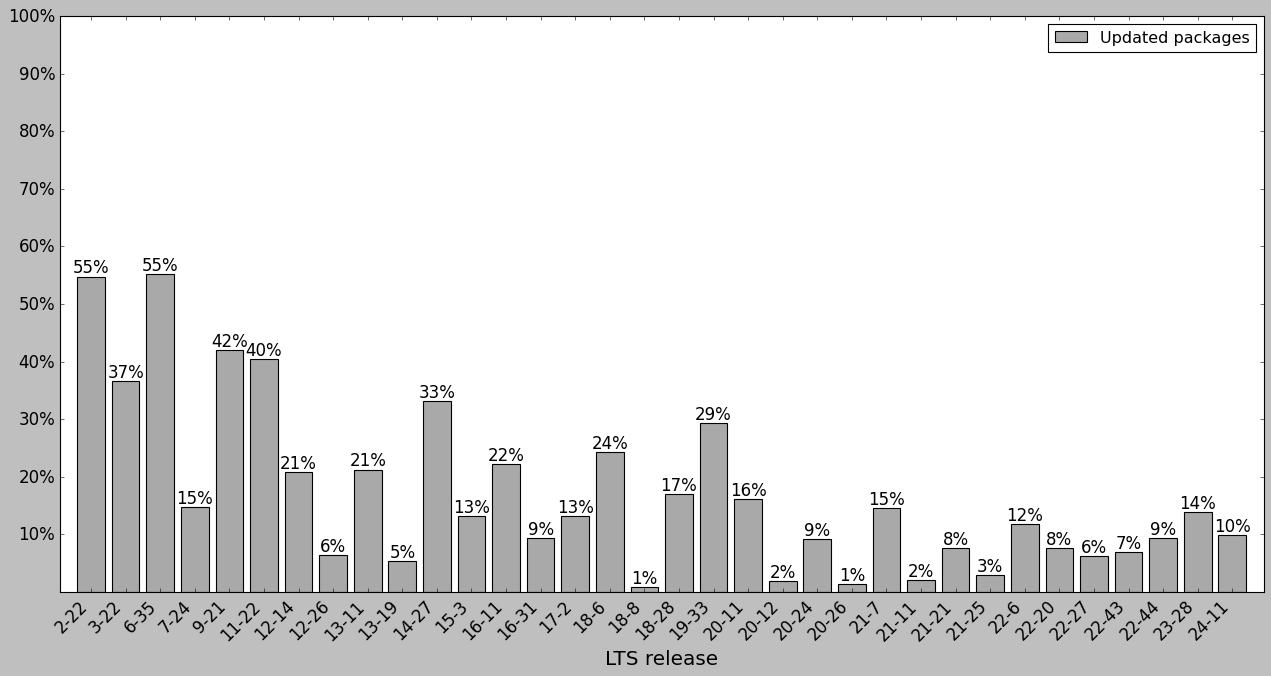

In [9]:
index = list(count_updated_packages_by_lts.keys())
updated_packages = list(count_updated_packages_by_lts.values())
fig, ax = plt.subplots(figsize=(14,8))
ax.margins(0.015) 
plt.subplots_adjust(bottom=0.1, right=1.2, top=1)

bar1 = ax.bar(index, updated_packages, width=0.8, color='darkgrey', align='center', label='Updated packages')
ax.bar_label(bar1, labels=list(map(lambda per: f"{round(per)}%", updated_packages)),fontsize=15)

ax.legend(loc='best')
ax.set_xlabel('LTS release',fontsize=18)
ax.set_xticks(lts_list[1:])
ax.set_xticklabels(lts_list[1:], fontsize=15, rotation=45, ha='right')
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'],fontsize=15)
plt.savefig("../../graphs/rq3.pdf", format='pdf', bbox_inches='tight')
plt.show()